In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot-Style festlegen
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Bereinigte Daten laden
df = pd.read_csv('../data/autoscout24_cleaned.csv')
print(f"Datensatz erfolgreich geladen: {df.shape[0]} Zeilen, {df.shape[1]} Spalten.")
df.head()

Datensatz erfolgreich geladen: 44107 Zeilen, 9 Spalten.


,mileage,make,model,fuel,gear,offerType,price,hp,year
0,235000,BMW,316,Diesel,Manual,Used,6800,116.0,2011
1,92800,Volkswagen,Golf,Gasoline,Manual,Used,6877,122.0,2011
2,149300,SEAT,Exeo,Gasoline,Manual,Used,6900,160.0,2011
3,96200,Renault,Megane,Gasoline,Manual,Used,6950,110.0,2011
4,156000,Peugeot,308,Gasoline,Manual,Used,6950,156.0,2011


In [2]:
total_cars = len(df)
min_year = int(df['year'].min())
max_year = int(df['year'].max())

print("=== 1.2 ANALYSE: ANZAHL & ZEITRAUM ===")
print(f"• Erfasste/Verkaufte Autos: {total_cars:,} Fahrzeuge")
print(f"• Erfasster Zeitraum: {min_year} bis {max_year} (Spanne: {max_year - min_year + 1} Jahre)")

=== 1.2 ANALYSE: ANZAHL & ZEITRAUM ===
• Erfasste/Verkaufte Autos: 44,107 Fahrzeuge
• Erfasster Zeitraum: 2011 bis 2021 (Spanne: 11 Jahre)


=== 1.2 ANALYSE: MARKEN ===
• Anzahl erfasster Automarken: 73

• Die 10 am häufigsten erfassten Marken:
make
Volkswagen       6693
Opel             4583
Ford             4274
Skoda            2739
Renault          2692
Audi             2547
BMW              2364
Mercedes-Benz    2270
SEAT             1831
Hyundai          1742
Name: count, dtype: int64


C:\Users\CNN4LIVE\AppData\Local\Temp\ipykernel_13588\2879802410.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_makes.head(10).index, y=top_makes.head(10).values, palette="viridis")


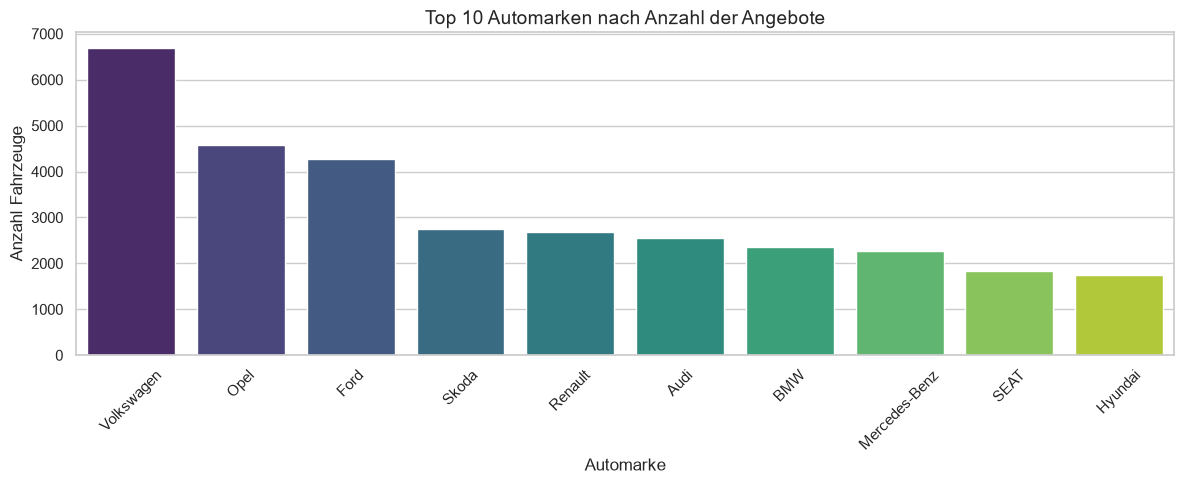

In [4]:
num_makes = df['make'].nunique()
top_makes = df['make'].value_counts()

print("=== 1.2 ANALYSE: MARKEN ===")
print(f"• Anzahl erfasster Automarken: {num_makes}")
print("\n• Die 10 am häufigsten erfassten Marken:")
print(top_makes.head(10))

# Visualisierung der Top 10 Marken
plt.figure(figsize=(12, 5))
sns.barplot(x=top_makes.head(10).index, y=top_makes.head(10).values, palette="viridis")
plt.title("Top 10 Automarken nach Anzahl der Angebote", fontsize=14)
plt.xlabel("Automarke")
plt.ylabel("Anzahl Fahrzeuge")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

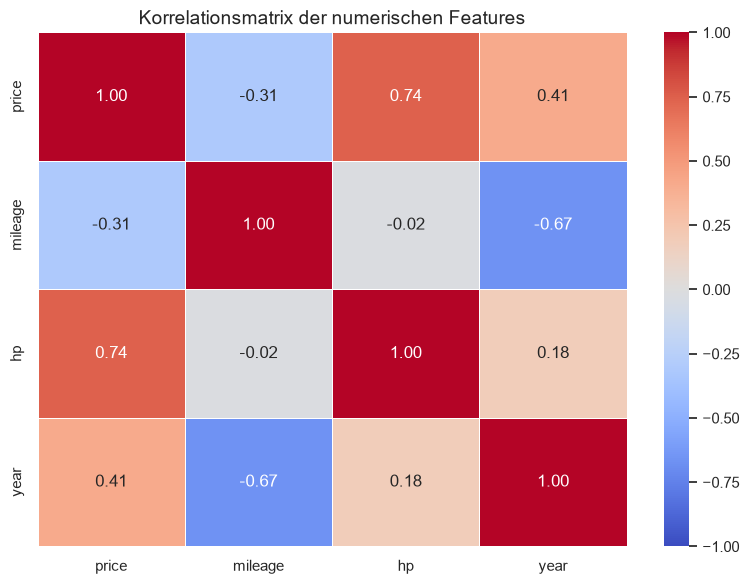

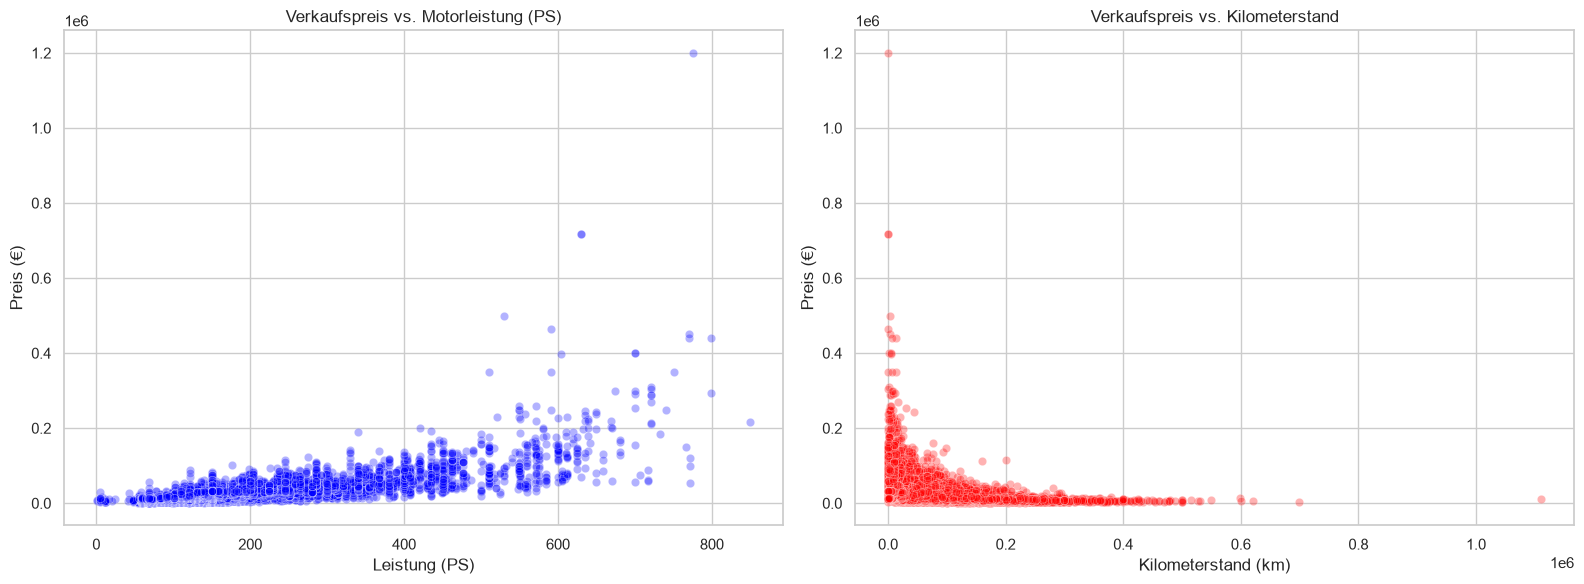

In [5]:
# Numerische Merkmale auswählen
numeric_cols = ['price', 'mileage', 'hp', 'year']
corr_matrix = df[numeric_cols].corr()

# Korrelationsmatrix als Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title("Korrelationsmatrix der numerischen Features", fontsize=14)
plt.tight_layout()
plt.show()

# Scatterplots der wichtigsten Beziehungen
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Preis vs. Leistung (hp)
sns.scatterplot(data=df, x='hp', y='price', alpha=0.3, ax=axes[0], color='blue')
axes[0].set_title("Verkaufspreis vs. Motorleistung (PS)")
axes[0].set_xlabel("Leistung (PS)")
axes[0].set_ylabel("Preis (€)")

# Preis vs. Kilometerstand (mileage)
sns.scatterplot(data=df, x='mileage', y='price', alpha=0.3, ax=axes[1], color='red')
axes[1].set_title("Verkaufspreis vs. Kilometerstand")
axes[1].set_xlabel("Kilometerstand (km)")
axes[1].set_ylabel("Preis (€)")

plt.tight_layout()
plt.show()

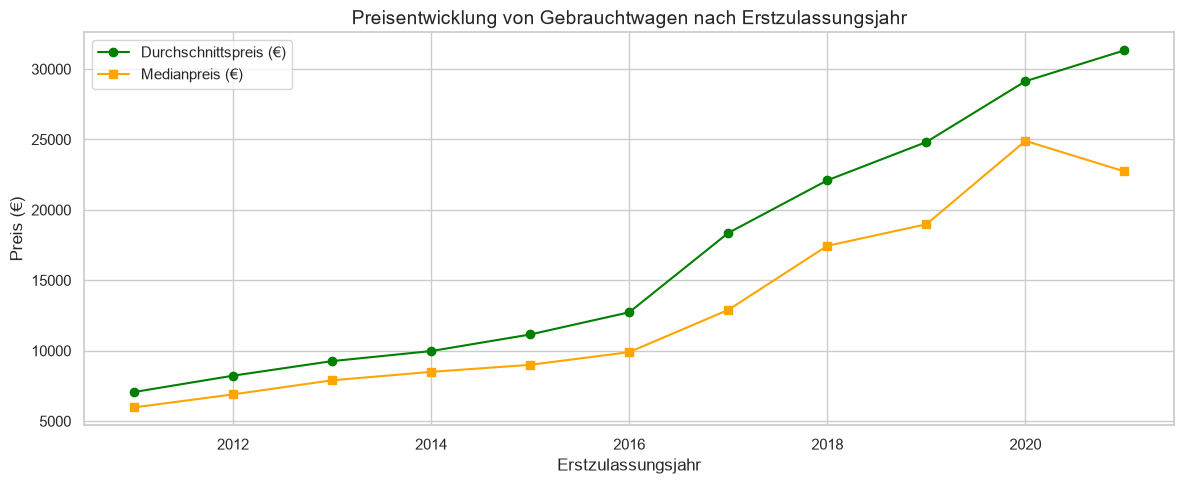

In [6]:
# Aggregation nach Baujahr
yearly_stats = df.groupby('year').agg(
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    car_count=('price', 'count')
).reset_index()

# Trend der Preisentwicklung über die Jahre
plt.figure(figsize=(12, 5))
plt.plot(yearly_stats['year'], yearly_stats['avg_price'], label='Durchschnittspreis (€)', marker='o', color='green')
plt.plot(yearly_stats['year'], yearly_stats['median_price'], label='Medianpreis (€)', marker='s', color='orange')
plt.title("Preisentwicklung von Gebrauchtwagen nach Erstzulassungsjahr", fontsize=14)
plt.xlabel("Erstzulassungsjahr")
plt.ylabel("Preis (€)")
plt.legend()
plt.tight_layout()
plt.show()